# Cavità acustica risonante
Giovanni Nicola D'Aloisio, n. di matricola 494722; prova svolta l'11 maggio 2021.

---

## Introduzione
<p align="justify">Quando un tubo contenente un gas a una certa temperatura viene sottoposto a una serie di onde acustiche, l'onda armonica che ne risulta si propaga fino a raggiunge l'altra estremità, riflettendosi e tornando indietro con la medesima frequenza ed ampiezza. L'onda che rimbalza si sovrappone a quella successiva, e tale interferenza conduce alla formazione di un'onda stazionaria, della quale è possibile stimare, a partire dal suo spettro in frequenza, il fattore di merito. Il calcolo della sua velocità di propagazione, inoltre, porta a determinare il valore della velocità del suono nell'aria e definire il Kelvin, attraverso la costante di Boltzmann  $k_B$, con le relative incertezze.

## Scopi della prova
Gli obiettivi di questa prova sono:

* Misurare lo spettro in frequenza della cavità acustica, per determinare il fattore di qualità $Q$ delle prime tre risonanze armoniche;
* Determinare la velocità del suono $c_s$ in aria;
* Determinare la costante di Boltzmann $k_B \pm \delta k_B$.



## Apparato sperimentale
Per raggiungere gli obiettivi della prova si dispone di:
* Un tubo in plexiglass contenente aria, che costituisce la cavità acustica;
* Un altoparlante, collegato a un'estremità della cavità e alimentato da un generatore di frequenze, che genera le onde sonore;
* Un microfono, collegato a all'altra estremità del tubo, che visualizza su un oscilloscopio l'onda acustica;
* Un termometro, per misurare la temperatura ambientale;
* Un metro a nastro, per misurare le dimensioni della cavità.

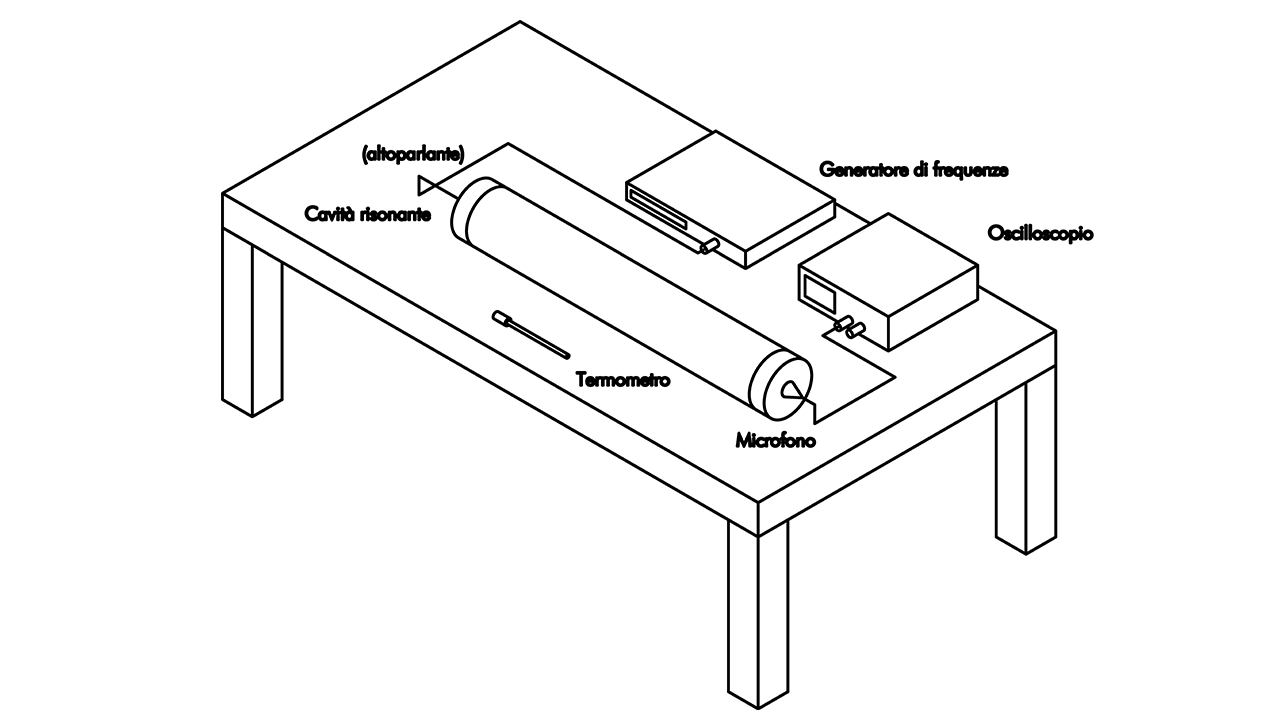

## Procedura
<p align="justify">In un oscillatore reale immerso in un fluido come l'aria sono sempre presenti forze di attrito, per cui per mantenerlo in oscillazione occorre fornire una certa quantità di energia, attraverso una forza periodica esterna. Si dimostra che in un intervallo di tempo sufficientemente elevato, il regime transitorio si estingue, domina la soluzione stazionaria, e le sue caratteristiche dipendono unicamente dalla forza esterna $F_0$.

<p align="justify">Nella prima parte della prova, si registrano una ventina di valori di frequenza e ampiezza dell'onda stazionaria nel tubo intorno a ciascuna delle prime tre frequenze di risonanza; con tali dati si esegue il best-fit della legge:

> $A_f=\frac{F_0 / m}{\sqrt{(\omega_0^2 - \omega_f^2)^2+4\gamma^2\omega_f^2}}$

<p align="justify">L'ampiezza dipende dall'intensità della forza esterna e dalla sua frequenza. La sua frequenza naturale $\omega_0$ è la sua frequenza quando non sono presenti forze esterne, ma se quella forzante $\omega_f$ fosse sufficientemente vicina a essa, il sistema oscillerebbe con ampiezza relativamente più alta. Questo fenomeno prende il nome di risonanza e tale frequenza è detta frequenza di risonanza.

<p align="justify">Per ogni frequenza di risonanza, inoltre, si possono calcolare i fattori di qualità:

> $Q=\omega t=\frac{\omega}{2\gamma}$

<p align="justify">che quantificano il grado di smorzamento dell'oscillazione (se lo smorzamento è debole), e che aumenta al diminuire dell'energia dissipata.

<p align="justify">Nella seconda parte della prova, sapendo che la pulsazione e la frequenza di un'oscillazione sono legate dalla legge $\omega = 2 \pi f$, e che il vettore d'onda è definito come $k_n=\frac{n\pi}{L}$, dove $n$ è il numero dell'armonica ed $L \pm \delta L$ è la lunghezza della cavità, si costruisce un diagramma $\omega$ - $k_n$, che permette di stimare la velocità $c_s \pm \delta c_s$ di propagazione del suono nell'aria secondo la legge:

> $\omega_n = k_n c_s$.

<p align="justify">Chiaramente, tale valore dipende anche dalla temperatura $T \pm \delta T$ dell'aria contenuta nel tubo.

<p align="justify">Infine, utilizzando l'equazione di stato dei gas perfetti, risulta:

> $c_s=\sqrt{\gamma P_0 \over \rho_0} \quad \Rightarrow \quad k_B=\frac{c_s^2M}{\gamma N_A T} \quad$ (con $P_0, \rho_0$ rispettivamente pressione e densità dell'aria)

<p align="justify">Nota la temperatura ambientale $T \pm \delta T$, per termometria acustica si determina la costante di Boltzmann $k_B \pm \delta k_B$. Si noti che in quest'ultima legge $N_A$ è il numero di Avogadro, $M$ è la massa molare dell'aria, $\gamma$ è il coefficiente di dilatazione adiabatica dell'aria (da non confondere con il coefficiente di smorzamento $\gamma$ precedentemente definito).

## Analisi dei dati sperimentali

In questa sezione sono riportati i dati sperimentali e gli script in Python utilizzati per la loro analisi statistica, con i relativi risultati (valori numerici e grafici).



In [ ]:
# Da eseguire all'inizio
import numpy as np
from matplotlib import pyplot as plt 
from scipy.optimize import curve_fit 
from scipy import odr
from scipy import constants
from ipywidgets import interact, interact_manual, FloatSlider, Checkbox, BoundedFloatText
from google.colab import files
import json

### Curve di risonanza e fattori di qualità

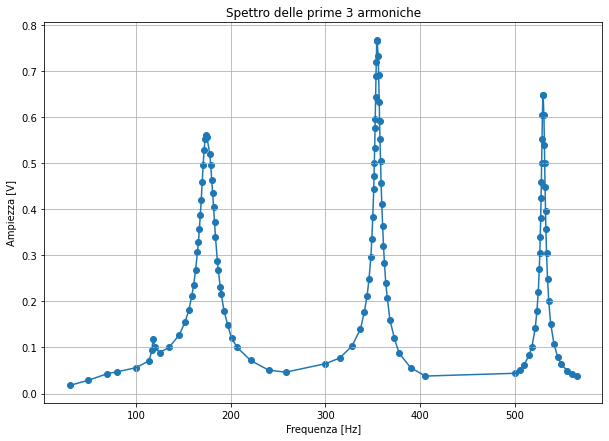

In [ ]:
# Raccolta e plot dei dati sperimentali as-they-are
 
frequenza_err = 0.1             # Errore assoluto su ogni misura di frequenza (generatore di frequenze)
ampiezza_err = 0.0001           # Errore assoluto su ogni misura di ampiezza (oscilloscopio)
 
# Prima armonica
 
spettro1 = [[30.0, 0.0176], [50.0,0.029], [70.0, 0.0432], [80.0, 0.0472], [100.0, 0.056], [114.0, 0.0712], [117.0, 0.095], [118.0, 0.118], [120.0, 0.102], [125.0, 0.089], [135.0, 0.100], [146.0, 0.128], [152.0, 0.156], [156.0, 0.182], [159.0, 0.212], [161.0, 0.236], [163.0, 0.268], [165.0, 0.308], [166.0, 0.328], [167.0, 0.356], [168.0, 0.388], [169.0, 0.420], [170.0,0.460], [171.0,0.496], [172.0,0.528], [173.0,0.552], [174.0,0.560], [175.0, 0.556], [178.0, 0.520], [179.0, 0.496], [180.0, 0.464], [181.0, 0.436], [182.0, 0.404], [183.0, 0.372], [184.0, 0.340], [186.0, 0.288], [187.0, 0.268], [189.0, 0.232], [190.0, 0.216], [193.0, 0.180], [197.0, 0.148], [201.0, 0.120], [207.0, 0.100], [221.0, 0.072], [240.0, 0.051], [258.0, 0.0464]]
 
_spettro1 = np.array(spettro1)
 
frequenza1 = _spettro1[:,0]
ampiezza1 = _spettro1[:,1]
 
# Seconda armonica
 
spettro2 = [[300.0, 0.0648], [315.0, 0.077], [328.0, 0.103], [337.0, 0.140], [341.0, 0.176], [344.0, 0.212], [346.0, 0.248], [348.0, 0.296], [349.0, 0.336], [350.0, 0.384], [351.0, 0.444], [351.3, 0.472], [351.6, 0.500], [352.0, 0.532], [352.4, 0.576], [352.6, 0.596], [353.0, 0.644], [353.4, 0.688], [353.7,0.720], [354.2,0.764], [354.5,0.768], [355.7,0.732], [356.2,0.692], [356.8, 0.632], [357.2, 0.592], [357.6, 0.552], [358.2, 0.504], [358.8, 0.456], [359.5, 0.412], [360.4, 0.364], [361.3, 0.320], [362.3, 0.284], [363.7, 0.240], [365.3, 0.208], [368.1, 0.160], [372.8, 0.120], [377.7, 0.088], [390, 0.056], [405.6, 0.038]]
 
_spettro2 = np.array(spettro2)
 
frequenza2 = _spettro2[:,0]
ampiezza2 = _spettro2[:,1]
 
# Terza armonica
 
spettro3 = [[500.0, 0.044], [505.0, 0.052], [510.0, 0.063], [515.0, 0.084], [518.0, 0.102], [521.4, 0.142], [523.3, 0.180], [524.6, 0.220], [525.7, 0.270], [526.3, 0.304], [526.7, 0.340], [527.2, 0.380], [527.6, 0.424], [527.9, 0.460], [528.2, 0.500], [528.6, 0.552], [529.0, 0.604], [529.5, 0.648], [529.7, 0.648], [530.6, 0.604], [531.1,0.540], [531.4,0.500], [531.8,0.448], [532.3,0.396], [532.7,0.356], [533.4, 0.304], [534.4, 0.248], [535.7, 0.200], [537.7, 0.152], [541.2, 0.108], [545.0, 0.080], [549.1, 0.0632], [555.0, 0.050], [560.0, 0.043], [565.1, 0.038]]
 
_spettro3 = np.array(spettro3)
 
frequenza3 = _spettro3[:,0]
ampiezza3 = _spettro3[:,1]
 
# Spettro completo
 
spettro = spettro1 + spettro2 + spettro3
 
_spettro = np.array(spettro)
 
frequenza = _spettro[:,0]
ampiezza = _spettro[:,1]
 
plt.figure(figsize=(10, 7))
plt.grid()
plt.errorbar(frequenza,ampiezza,xerr=frequenza_err,yerr=ampiezza_err)
plt.title("Spettro delle prime 3 armoniche")
plt.xlabel("Frequenza [Hz]")
plt.ylabel("Ampiezza [V]")
_ = plt.scatter(frequenza, ampiezza)

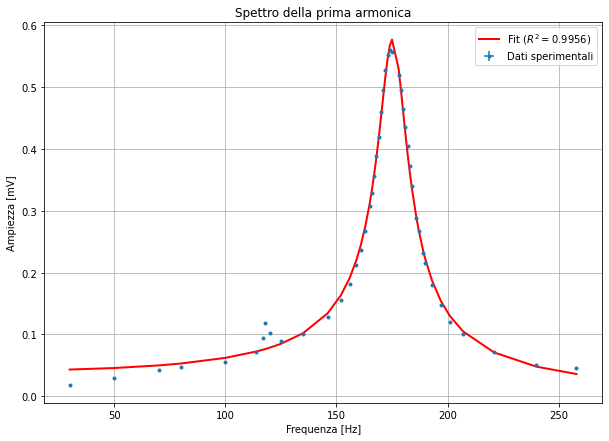

      F₀/m = 51111.234432 +- 689.068077
        ω₀ = -1102.535993 +- 0.570298
         γ = -40.180791 +- 0.817841
R² = 0.9956040084187985
Q = 13.719690083171916


In [ ]:
# Definizione della funzione di fit per la prima armonica
 
omegaf1 = frequenza1*2*np.pi                   # Lista contenente le pulsazioni per il fit
 
def amplitude(omegaf1,roba,omega0,gamma): 
  return roba/np.sqrt(((omega0**2-omegaf1**2)**2)+(4*(gamma**2)*(omegaf1**2)))
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_amplitude(roba, omega0, gamma, print_output=True, plot_guess=False):
 
  guess = np.array([roba,omega0,gamma]) # Array delle stime iniziali
 
  global popt, pcov
 
  plt.figure(figsize=(10, 7))
  popt, pcov = curve_fit(amplitude, omegaf1, ampiezza1, p0=guess)
 
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = ampiezza1 - amplitude(omegaf1,popt[0],popt[1],popt[2])
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((ampiezza1-np.mean(ampiezza1))**2)
  r_squared = 1 - (ss_res / ss_tot)
 
  # Calcolo del fattore di merito
 
  fattore = popt[1]/(2*popt[2])
 
  # Plot dei risultati
 
  if plot_guess:
    plt.plot(frequenza1, amplitude(frequenza1, guess[0], guess[1], guess[2]),'--', color=[0.3,0.7,0], label="Guess", linewidth=2) # Plot guess
 
  _ = plt.errorbar(frequenza1,ampiezza1,xerr=frequenza_err,yerr=ampiezza_err,capsize=0,fmt='.',label="Dati sperimentali")
  plt.plot(frequenza1,amplitude(omegaf1,popt[0],popt[1],popt[2]),color=[1,0,0],label="Fit ($R^2=${:.4f})".format(r_squared),linewidth=2)
  plt.grid(which='both')
  plt.title("Spettro della prima armonica")
  plt.xlabel("Frequenza [Hz]")
  plt.ylabel("Ampiezza [mV]")
  plt.legend();
  plt.show()
  
  if print_output:
    label = ["F₀/m", "ω₀", "γ"]
    for l, v, e in zip(label, popt, np.sqrt(np.diag(pcov))) :
      print("%10s = %9.6f +- %7.6f" % (l ,v, e))
    print("R² = "+str(r_squared))
    print("Q = "+str(fattore))
 
# Interattivo
interact_manual.opts["manual_name"]= 'Fit'
_=interact_manual(fitplot_amplitude, roba=BoundedFloatText(max=100000,step=1e-2,description='F₀/m'),
                  omega0=BoundedFloatText(max=500000, step=1e-2, description='ω₀'),
                  gamma=BoundedFloatText(max=100000,step=1e-2,description='γ'),
                  print_output=Checkbox(value=True, description='Visualizza parametri fit'),
                  plot_guess=Checkbox(value=False ,description='Visualizza funzione di prova'))

# Parametri di guess consigliati: 5, 1, 10

In [ ]:
# Definizione della funzione di fit per la seconda armonica
 
omegaf2 = frequenza2*2*np.pi                   # Lista contenente le pulsazioni per il fit
 
def amplitude(omegaf2,roba,omega0,gamma): 
  return roba/np.sqrt(((omega0**2-omegaf2**2)**2)+(4*(gamma**2)*(omegaf2**2)))
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_amplitude(roba, omega0, gamma, print_output=True, plot_guess=False):
 
  guess = np.array([roba,omega0,gamma]) # Array delle stime iniziali
 
  global popt, pcov
 
  plt.figure(figsize=(10, 7))
  popt, pcov = curve_fit(amplitude, omegaf2, ampiezza2, p0=guess)
 
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = ampiezza2 - amplitude(omegaf2,popt[0],popt[1],popt[2])
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((ampiezza2-np.mean(ampiezza2))**2)
  r_squared = 1 - (ss_res / ss_tot)
 
  # Calcolo del fattore di merito
 
  fattore = popt[1]/(2*popt[2])
 
  # Plot dei risultati
 
  if plot_guess:
    plt.plot(frequenza2, amplitude(frequenza2, guess[0], guess[1], guess[2]),'--', color=[0.3,0.7,0], label="Guess", linewidth=2) # Plot guess
 
  _ = plt.errorbar(frequenza2,ampiezza2,xerr=frequenza_err,yerr=ampiezza_err,capsize=0,fmt='.',label="Dati sperimentali")
  plt.plot(frequenza2,amplitude(omegaf2,popt[0],popt[1],popt[2]),color=[1,0,0],label="Fit ($R^2=${:.4f})".format(r_squared),linewidth=2)
  plt.grid(which='both')
  plt.title("Spettro della seconda armonica")
  plt.xlabel("Frequenza [Hz]")
  plt.ylabel("Ampiezza [mV]")
  plt.legend();
  plt.show()
  
  if print_output:
    label = ["F₀/m", "ω₀", "γ"]
    for l, v, e in zip(label, popt, np.sqrt(np.diag(pcov))) :
      print("%10s = %9.6f +- %7.6f" % (l ,v, e))
    print("R² = "+str(r_squared))
    print("Q = "+str(fattore))
 
# Interattivo
interact_manual.opts["manual_name"]= 'Fit'
_=interact_manual(fitplot_amplitude, roba=BoundedFloatText(max=100000,step=1e-2,description='F₀/m'),
                  omega0=BoundedFloatText(max=500000, step=1e-2, description='ω₀'),
                  gamma=BoundedFloatText(max=100000,step=1e-2,description='γ'),
                  print_output=Checkbox(value=True, description='Visualizza parametri fit'),
                  plot_guess=Checkbox(value=False ,description='Visualizza funzione di prova'))

# Parametri di guess consigliati: 10, 10, 10

interactive(children=(BoundedFloatText(value=0.0, description='F₀/m', max=100000.0, step=0.01), BoundedFloatTe…

In [ ]:
# Definizione della funzione di fit per la terza armonica
 
omegaf3 = frequenza3*2*np.pi                   # Lista contenente le pulsazioni per il fit
 
def amplitude(omegaf3,roba,omega0,gamma): 
  return roba/np.sqrt(((omega0**2-omegaf3**2)**2)+(4*(gamma**2)*(omegaf3**2)))
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_amplitude(roba, omega0, gamma, print_output=True, plot_guess=False):
 
  guess = np.array([roba,omega0,gamma]) # Array delle stime iniziali
 
  global popt, pcov
 
  plt.figure(figsize=(10, 7))
  popt, pcov = curve_fit(amplitude, omegaf3, ampiezza3, p0=guess)
 
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = ampiezza3 - amplitude(omegaf3,popt[0],popt[1],popt[2])
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((ampiezza3-np.mean(ampiezza3))**2)
  r_squared = 1 - (ss_res / ss_tot)
 
  # Calcolo del fattore di merito
 
  fattore = popt[1]/(2*popt[2])
 
  # Plot dei risultati
 
  if plot_guess:
    plt.plot(frequenza3, amplitude(frequenza3, guess[0], guess[1], guess[2]),'--', color=[0.3,0.7,0], label="Guess", linewidth=2) # Plot guess
 
  _ = plt.errorbar(frequenza3,ampiezza3,xerr=frequenza_err,yerr=ampiezza_err,capsize=0,fmt='.',label="Dati sperimentali")
  plt.plot(frequenza3,amplitude(omegaf3,popt[0],popt[1],popt[2]),color=[1,0,0],label="Fit ($R^2=${:.4f})".format(r_squared),linewidth=2)
  plt.grid(which='both')
  plt.title("Spettro della terza armonica")
  plt.xlabel("Frequenza [Hz]")
  plt.ylabel("Ampiezza [mV]")
  plt.legend();
  plt.show()
  
  if print_output:
    label = ["F₀/m", "ω₀", "γ"]
    for l, v, e in zip(label, popt, np.sqrt(np.diag(pcov))) :
      print("%10s = %9.6f +- %7.6f" % (l ,v, e))
    print("R² = "+str(r_squared))
    print("Q = "+str(fattore))
 
# Interattivo
interact_manual.opts["manual_name"]= 'Fit'
_=interact_manual(fitplot_amplitude, roba=BoundedFloatText(max=100000,step=1e-2,description='F₀/m'),
                  omega0=BoundedFloatText(max=500000, step=1e-2, description='ω₀'),
                  gamma=BoundedFloatText(max=100000,step=1e-2,description='γ'),
                  print_output=Checkbox(value=True, description='Visualizza parametri fit'),
                  plot_guess=Checkbox(value=False ,description='Visualizza funzione di prova'))\

# Parametri di guess consigliati: 20, 20, 20

interactive(children=(BoundedFloatText(value=0.0, description='F₀/m', max=100000.0, step=0.01), BoundedFloatTe…

### Determinazione della velocità del suono nell'aria

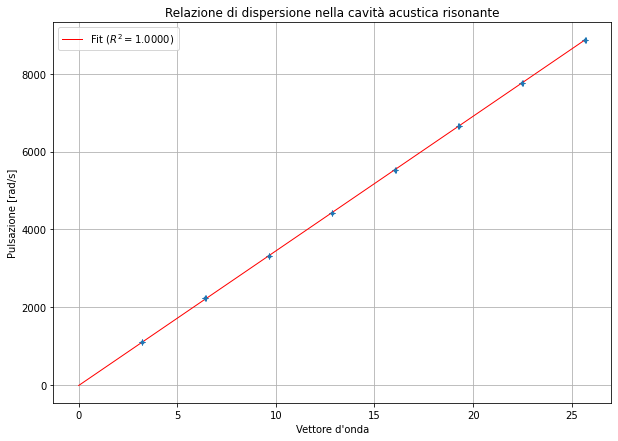

y₀ =    -8.2954 +/- 4.7787
c =   345.6560 +/- 0.6495
R² = 0.9999867510024797


In [ ]:
# Importazione dei dati per il fit
 
L = 0.978                        # Lunghezza della cavità tra microfono e altoparlante
L_err = 0.001                    # Errore assoluto sulla lunghezza precedente
L_percent_err = L_err/L          # Errore relativo sulla lunghezza precedente
f_err = 0.01                     # Errore assoluto sulla frequenza misurata

# dati è una lista di liste [n, f_n] dove n = numero dell'armonica e f_n = frequenza in Hz
 
dati_raw = [[1, 174.85], [2, 354.54], [3, 529.73], [4, 705.11], [5, 881.12], [6, 1058.40], [7, 1233.37], [8, 1410.65]]
 
dati = []

for raw in dati_raw:
  final = [np.pi*raw[0]/L, 2*np.pi*raw[1]]
  final.append(np.pi*raw[0]*L_err)               # Calcolo errore assoluto per k e append a final
  final.append(2*np.pi*f_err)                    # Calcolo errore assoluto per omega e append a final
  dati.append(final)
 
dati = np.array(dati)
 
kappa = dati[:,0]
omega = dati[:,1]
kappa_err = dati[:,2]
omega_err = dati[:,3]
 
# Definizione della funzione di fit
 
def retta(p,delta_x): 
  return p[0]+p[1]*delta_x
 
# Fitting routine, per definire la funzione che stampa il grafico e eseguire il fit dei dati
 
def fitplot_retta(y0, c, print_output=True, plot_guess=False):
  retta_model = odr.Model(retta)
  fit_data = odr.RealData(kappa, omega, sx=kappa_err, sy=omega_err)
  beta0 = np.array([y0,c])                                                      # Array dei guess iniziali
  
  fit = odr.ODR(fit_data, retta_model, beta0=beta0)
  global out
  out = fit.run()
  
  # Calcolo di R_squared, che valuta la bontà del fit
 
  residuals = omega - retta(out.beta, kappa)
  ss_res = np.sum(residuals**2)
  ss_tot = np.sum((omega-np.mean(omega))**2)
  r_squared = 1 - (ss_res / ss_tot)
  
  # Plot dei risultati del fit
 
  sample_x = np.linspace(0,np.amax(kappa), 1000)
  plt.show()
  plt.figure(figsize=(10,7))
 
  if plot_guess:
    plt.plot(sample_x, retta(beta0,sample_x),'-', color=[0.3,0.7,0], label="Guess", linewidth=2)
  
  plt.errorbar(kappa, omega, xerr=kappa_err, yerr=omega_err, linestyle='None', capsize=3, marker='.')
  plt.title("Relazione di dispersione nella cavità acustica risonante")
  plt.xlabel("Vettore d'onda")
  plt.ylabel("Pulsazione [rad/s]")
  plt.plot(sample_x, retta(out.beta, sample_x), color=[1,0,0], label="Fit ($R^2=${:.4f})".format(r_squared), linewidth=1)
  plt.grid(which='both')
  plt.legend()
  plt.show()
  
  if print_output:
    print("y₀ = {:10.4f} +/- {:2.4f}".format(out.beta[0],out.sd_beta[0]))
    print("c = {:10.4f} +/- {:2.4f}".format(out.beta[1],out.sd_beta[1]))
    print("R² = "+str(r_squared))
 
fitplot_retta(1, 8)

### Determinazione della costante di Boltzmann

In [ ]:
# Parametri di input (S.I.)

gamma_air = 1.4                 # Coefficiente di dilatazione adiabatica dell'aria (tabulato)
M_air = 0.0289647               # Massa molare dell'aria (tabulato)
N_A = 6.022*(10**23)            # Numero di Avogadro (tabulato)
temp = 295.7                    # Temperatura ambientale
temp_err = 0.1                  # Errore assoluto sulla temperatura precedente
epsilon_temp = temp_err/temp    # Errore relativo sulla temperatura precedente
c = out.beta[1]                 # Velocità del suono nell'aria
c_err = out.sd_beta[1]          # Errore assoluto sulla velocità precedente
epsilon_c = c_err/c             # Errore relativo sulla velocità precedente

# Calcolo costante di Boltzmann per termometria acustica

kappa_boltz = (c**2)*M_air/(gamma_air*N_A*temp)                       # Costante di Boltzmann
kappa_boltz_err = kappa_boltz * (2 * epsilon_c + epsilon_temp)        # Errore assoluto su k

# Stampa risultati

print("k = {} +/- {}".format(kappa_boltz,kappa_boltz_err))

k = 1.388153030578673e-23 +/- 5.686043383656192e-26


## Discussione dei risultati e conclusioni
<p align="justify">Dal fit dei dati sperimentali la legge $A(f)$ risulta verificata, e il minimo coefficiente di determinazione è quello della fondamentale; dal grafico corrispondente è evidente una non-linearità della legge, che si verifica alla base della curva stessa in corrispondenza dell'intervallo di frequenza [110, 130] Hz. Effettivamente, l'espressione di $A(f)$ è un modello teorico, dunque vale solo entro determinati limiti di approssimazione; è anche vero che misurando la frequenza di propagazione delle onde sonore nell'ambiente ad altoparlante spento, si registra una frequenza di fondo intorno a circa 120 Hz, che rientra nell'intorno suddetto. Si giustifica dunque la discrepanza tra la legge teorica e i dati sperimentali con la presenza di tale elemento di fondo, probabilmente dovuta a oggetti in movimento nell'ambiente circostante.

<p align="justify">Le frequenze calcolate trovano accordo con le condizioni del sistema e i fattori di smorzamento $\gamma$ sono, in modulo:

* $Q_\text{n=1} = 13.7$
* $Q_\text{n=2} = 61.5$
* $Q_\text{n=3} = 141$

<p align="justify">Dai best-fit si stima una velocità di propagazione del suono nell'aria pari a:

> $c_s = (345.7 \pm 0.7) \ \text{m/s} \quad$ per $\quad t=(22.7 \pm 0.1) \text{°C}$
 
<p align="justify">Un valore piuttosto vicino a quello tabulato, $\sim 343 \ \text{m/s} \ $, tralaltro relativo a una temperatura $ \ t=20 \text{°C}$, inferiore a quella dell'ambiente in cui si è svolta la prova.

<p align="justify">Infine, la costante di Boltzmann calcolata per termometria acustica è:

> $k_B = (1.388 \pm 0.006) \times 10^{-23} \ \text{J/K}$

<p align="justify">Che, anche in questo caso, non si discosta molto da quella vera $(1.38054 \times 10^{-23} \ \text{J/K})$.

<p align="justify">Per i risultati ottenuti, si considerano allora raggiunti tutti gli obiettivi della prova.